<a href="https://colab.research.google.com/github/Onyinyechukwu35/Financial-data-analysis/blob/main/Financialtask1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
pip install pandas matplotlib openpyxl

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving finance_transactions_dataset.xlsx to finance_transactions_dataset.xlsx


In [ ]:
import pandas as pd

df = pd.read_excel('finance_transactions_dataset.xlsx')
df.head()

,Transaction_ID,Company,Sector,Department,Transaction_Type,Category,Amount,Tax_Rate,Tax_Amount,Net_Amount,Currency,Transaction_Date,Approval_Status,Analyst
0,TXN1001,GreenEnergy,Energy,Marketing,Loan Repayment,NaN,104037.35,0.09,9363.36,94673.99,USD,2022-05-24,Pending,Analyst_B
1,TXN1002,LogiTrans,Logistics,IT,Loan Repayment,NaN,431438.64,0.10,43143.86,388294.78,USD,2023-08-04,Pending,Analyst_D
2,TXN1003,EduGroup,Education,Sales,Investment,NaN,494837.13,0.18,89070.68,405766.45,GBP,2023-08-05,Rejected,Analyst_B
3,TXN1004,HealthPlus,Healthcare,Sales,Revenue,NaN,59347.25,0.09,5341.25,54006.00,USD,2024-11-01,Pending,Analyst_A
4,TXN1005,EduGroup,Education,Finance,Loan Repayment,NaN,132500.40,0.15,19875.06,112625.34,GBP,2021-09-16,Approved,Analyst_C


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Transaction_ID    1000 non-null   object 
 1   Company           956 non-null    object 
 2   Sector            1000 non-null   object 
 3   Department        946 non-null    object 
 4   Transaction_Type  1000 non-null   object 
 5   Category          211 non-null    object 
 6   Amount            961 non-null    float64
 7   Tax_Rate          1000 non-null   float64
 8   Tax_Amount        1000 non-null   float64
 9   Net_Amount        960 non-null    float64
 10  Currency          1000 non-null   object 
 11  Transaction_Date  952 non-null    object 
 12  Approval_Status   961 non-null    object 
 13  Analyst           955 non-null    object 
dtypes: float64(4), object(10)
memory usage: 109.5+ KB


In [ ]:
df.describe().round(2)

,Amount,Tax_Rate,Tax_Amount,Net_Amount
count,961.00,1000.00,1000.00,960.00
mean,248309.09,0.18,44196.90,203859.56
std,145329.13,0.07,33447.57,120727.44
min,5132.61,0.05,355.38,3644.15
25%,115322.10,0.12,16896.31,94843.24
50%,250121.30,0.18,35780.50,200693.33
75%,375654.46,0.24,66364.00,308532.69
max,499771.64,0.30,148757.97,454365.87


In [ ]:
df.isnull().sum()

,0
Transaction_ID,0
Company,44
Sector,0
Department,54
Transaction_Type,0
Category,789
Amount,39
Tax_Rate,0
Tax_Amount,0
Net_Amount,40


In [ ]:
# prova gustace rount, net. noun, Transaction. Date ,
print('Rows remaining:', len(df))

Rows remaining: 1000


In [ ]:
df['Company'] = df['Company'].fillna('Unknown')
df['Department'] = df['Department'].fillna('Unknown')
df['Analyst'] = df['Analyst'].fillna('unknown')
df['Category'] = df['Category'].fillna('N/A')

In [ ]:
df[ 'Transaction_Date'] = pd. to_datetime(df['Transaction_Date'],
errors='coerce')
df.dropna(subset=['Transaction_Date'], inplace=True)
df['Year']= df['Transaction_Date'].dt.year
df['Month']= df['Transaction_Date'].dt.to_period('M').astype(str)
print( 'Sample dates:')
print(df[['Transaction_Date', 'Year', 'Month']]. head(3))

Sample dates:
  Transaction_Date  Year    Month
0       2022-05-24  2022  2022-05
1       2023-08-04  2023  2023-08
2       2023-08-05  2023  2023-08


In [ ]:
print( 'Final row count:', len(df))

Final row count: 952


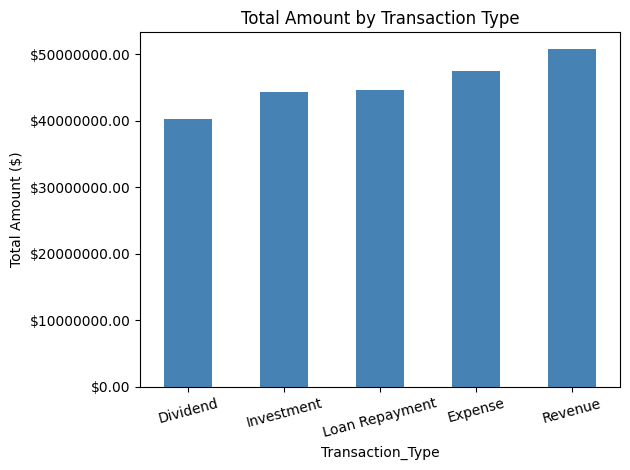

In [ ]:
df. groupby( 'Transaction_Type' )['Amount']. sum().sort_values().plot(kind='bar',
color='steelblue')
plt. title('Total Amount by Transaction Type')
plt. ylabel('Total Amount ($)')
plt.xticks(rotation=15)
money_fmt = mticker.FormatStrFormatter('$%.2f')
plt.gca().yaxis.set_major_formatter(money_fmt) # show real numbers, not 2.5e7
plt.tight_layout()
plt.show()

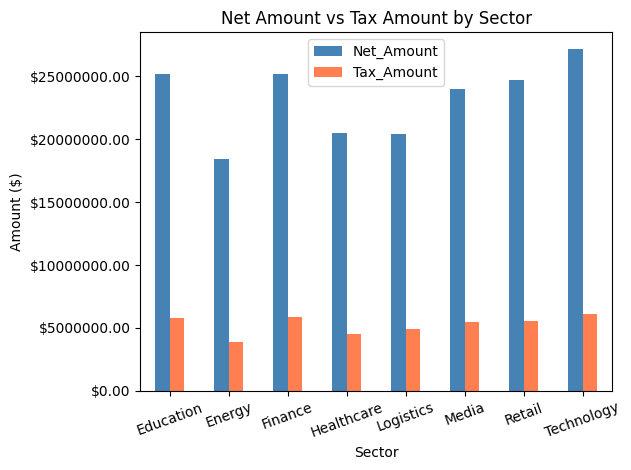

In [ ]:
df.groupby('Sector')[['Net_Amount', 'Tax_Amount']].sum().plot(kind='bar',
                                                          color=('steelblue',
                                                                 'coral'))
plt.title('Net Amount vs Tax Amount by Sector')
plt.ylabel('Amount ($)')
plt.xticks(rotation=20)
plt.gca().yaxis.set_major_formatter(money_fmt) # show real numbers, not 2.5e7
plt.tight_layout()
plt.show()

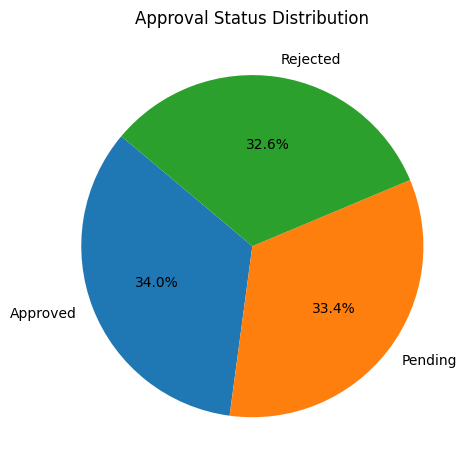

In [ ]:
df['Approval_Status'].value_counts().plot(kind='pie', autopct='%1.1f%%',
startangle=140)
plt.title('Approval Status Distribution')
plt.ylabel('')
# hides the default y-axis label on pie charts
plt.tight_layout()
plt.show()

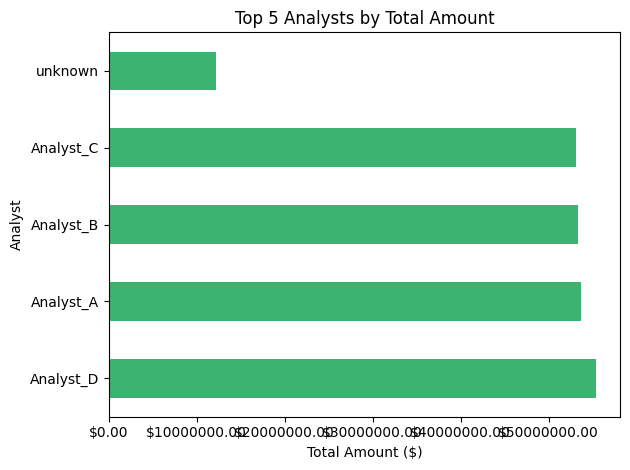

In [ ]:
df.groupby('Analyst')['Amount'].sum().nlargest(5).plot(kind='barh',
color='mediumseagreen')
plt.title('Top 5 Analysts by Total Amount')
plt.xlabel('Total Amount ($)')
plt.gca().xaxis.set_major_formatter(money_fmt) # x-axis for horizontal bars
plt.tight_layout()
plt.show()

In [ ]:
print('=' * 46)
print('\nFINANCE DATASET SUMMARY')
print('=' * 46)
print(f"Transactions: {len(df):,}")
print(f"Total Amount: ${df['Amount'].fillna(0).sum():,.2f}")
print(f"Total Tax Paid: ${df['Tax_Amount'].sum():,.2f}")
print(f"Total Net Amount: ${df['Net_Amount'].fillna(0).sum():,.2f}")
print(f"Avg Tax Rate: {df['Tax_Rate'].mean() * 100:.1f}%")
print(f"Approval Rate: {(df['Approval_Status'] == 'Approved').mean() * 100:.1f}%")
print(f"Top Sector: {df.groupby('Sector')['Amount'].sum().idxmax()}")
print(f"Top Analyst: {df.groupby('Analyst')['Amount'].sum().idxmax()}")
print('=' * 46)


FINANCE DATASET SUMMARY
Transactions: 952
Total Amount: $227,716,079.87
Total Tax Paid: $42,164,951.46
Total Net Amount: $185,453,376.88
Avg Tax Rate: 17.8%
Approval Rate: 32.7%
Top Sector: Technology
Top Analyst: Analyst_D


<Axes: xlabel='Currency'>

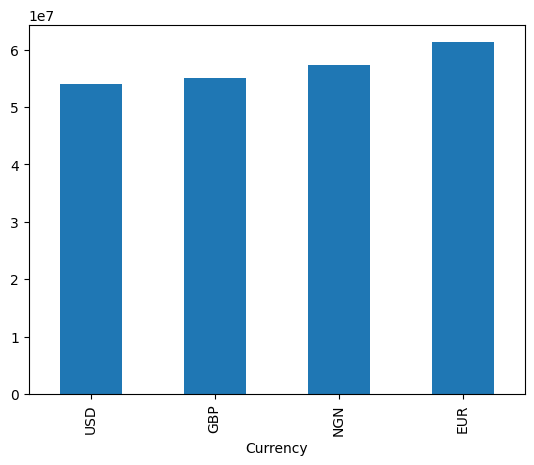

In [ ]:
df.groupby('Currency')['Amount'].sum().sort_values().plot(kind='bar')

<Axes: ylabel='Department'>

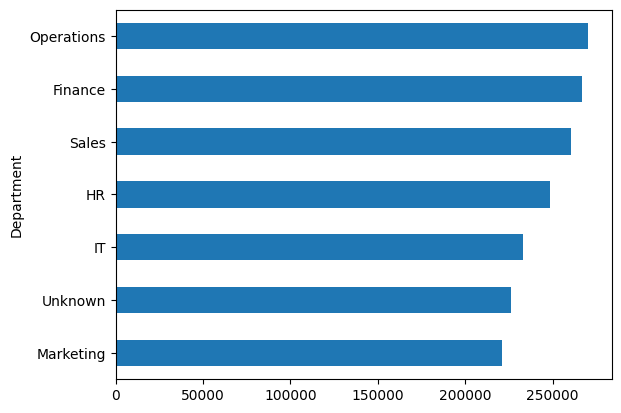

In [ ]:
df.groupby('Department')['Amount'].mean().sort_values().plot(kind='barh')